# Project Foundations for Data Science: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns



### Understanding the structure of the data

In [ ]:
# read the data
df = pd.read_csv('foodhub_order.csv')

# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# No of Rows and Columns in the Dataset
df.shape

(1898, 9)

#### Observations:  
There are 1898 Rows and 9 Columns in the FoodHub Dataset. That means the dataset contains 1898 obseravation with 9 Variables.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Use info() to print a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


In [ ]:
# Returns a Series containing the data type of the every column
df.dtypes

,0
order_id,int64
customer_id,int64
restaurant_name,object
cuisine_type,object
cost_of_the_order,float64
day_of_the_week,object
rating,object
food_preparation_time,int64
delivery_time,int64


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Check is there any missing data in the dataset
df.isna().any()

,0
order_id,False
customer_id,False
restaurant_name,False
cuisine_type,False
cost_of_the_order,False
day_of_the_week,False
rating,False
food_preparation_time,False
delivery_time,False


In [ ]:
# Another way to check out the missing values
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:
There are 1898 rows and 9 columns. The order_id and customer_id are integer datatypes, but they represent nominal categorical data because they are identifiers and do not have numerical meaning. The restuarant_name, cuisine_type, day_of_week are of object type and represents categorical (nominal) data. The rating,cost_of_the_order are quantitative data as they are measurable numerical values and can perform numerical operations. The food_preparation_time and delivery_time represent continuos quantative data as mean, median,etc can be performed.

The columns do not miss any value. 'pf.isna.any()' confirms will all 'False' in columns O

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Statistical Summary of the all Data
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1898.0,NaN,NaN,NaN,1477495.5,548.049724,1476547.0,1477021.25,1477495.5,1477969.75,1478444.0
customer_id,1898.0,NaN,NaN,NaN,171168.478398,113698.139743,1311.0,77787.75,128600.0,270525.0,405334.0
restaurant_name,1898,178,Shake Shack,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1898,14,American,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1898.0,NaN,NaN,NaN,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
day_of_the_week,1898,2,Weekend,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1898,4,Not given,736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_preparation_time,1898.0,NaN,NaN,NaN,27.37197,4.632481,20.0,23.0,27.0,31.0,35.0
delivery_time,1898.0,NaN,NaN,NaN,24.161749,4.972637,15.0,20.0,25.0,28.0,33.0


In [ ]:
# Statistical Summary of the data (numerical data)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


#### Observations:
The data set shows that minimum time to prepare the food is 20 mins where as the maximum time is 35 mins. The average time to prepare the food is 27 mins.


### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# counts the unique values in the data set
df['rating'].value_counts()


,count
rating,
Not given,736
5,588
4,386
3,188


#### Observations:

A total of 736 orders, the customers did not provide any rating and it is captured as 'Not given'

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

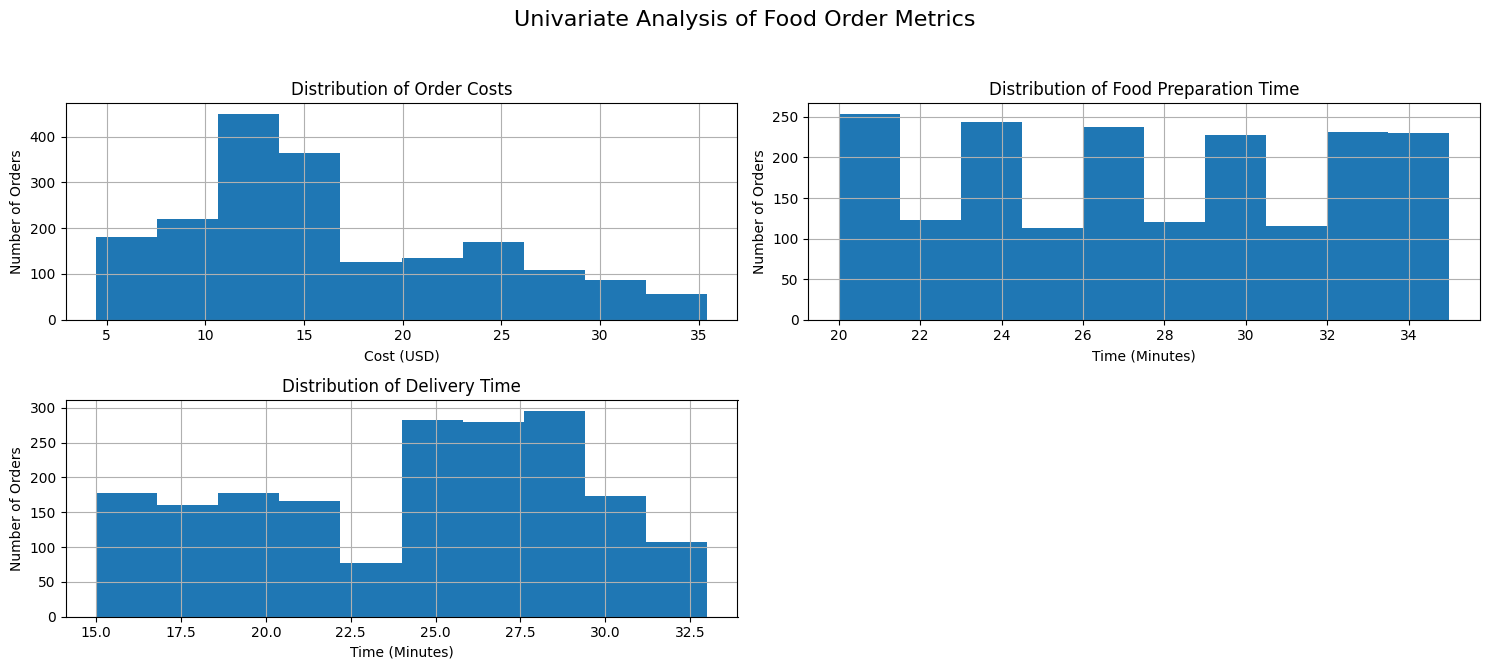

In [ ]:
# Distribution Plot for Univariate Analysis using histogram
axes=df[['cost_of_the_order','food_preparation_time','delivery_time']].hist(figsize=(15,7))

axes[0,0].set_title('Distribution of Order Costs')
axes[0,0].set_xlabel('Cost (USD)')
axes[0,0].set_ylabel('Number of Orders')

axes[0,1].set_title('Distribution of Food Preparation Time')
axes[0,1].set_xlabel('Time (Minutes)')
axes[0,1].set_ylabel('Number of Orders')

axes[1,0].set_title('Distribution of Delivery Time')
axes[1,0].set_xlabel('Time (Minutes)')
axes[1,0].set_ylabel('Number of Orders')

plt.suptitle('Univariate Analysis of Food Order Metrics',fontsize=16)
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()

**Observation**

Based on the histograms generated by Cost of the order, Food Preparation Time and Delivery time, these are the key observations -  
1. Cost of the Order
      * Skewness - The distribution is right skewed. This means the majority of the order is lower value
      * Central Tendency - The high frequency of the order is between the range `$12` to `$15` range. The median of the order is `$14.14` while the average cost is `$16.49`. This is due to some expensive order.
      * Range - The cost of the order range between `$4.5` - `$35.4`

2. Food Preparation Time
      * Skewness - The distribution is fairly uniform. This means the all the food order was prepared consistently at the same time.
      * Central Tendency - The data is well centered because the mean and the median of the data is 27 mins
      * Range - The time taken to prepare the food ranges strictly between 20 mins - 35 mins

3. Delivery Time
      * Skewness - The distribution is somewhat spread out. It shows variation in its peaks.
      * Central Tendency - The average delivery time is 24 mins. The median of the delivery time is 25 mins.
      * Range - The time taken to deliver the food is between 15 mins - 33 mins



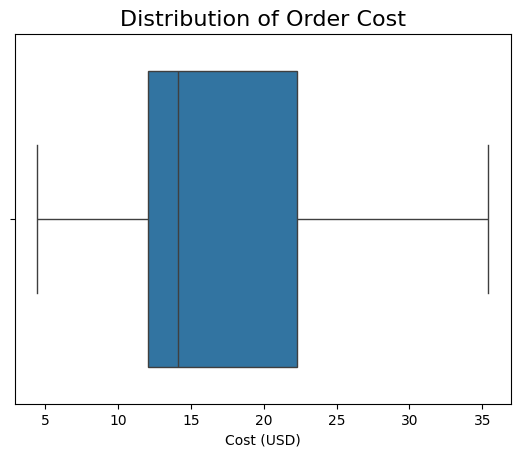

In [ ]:
# Distribution plot of cost of the order across the Food Hub platform
sns.boxplot(data=df,x='cost_of_the_order')
plt.title('Distribution of Order Cost',fontsize=16)
plt.xlabel('Cost (USD)')
plt.show()


**Observation**

* The data is right skewed. The 50th percentile of the order cost is `$14.4` which is the median.
* The Most order cost ranges between `$12` and `$15`.
* There is no outlier found in this specific plot which means the order cost is consistent across the platform.
* The box spans between `$12`(Q1) and `$22`(Q3). This shows the customer of Food Hub platform usually spends between `$12` and `$22` per order.


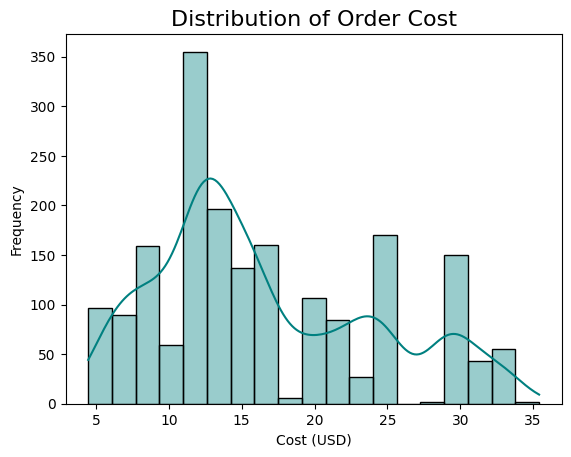

In [ ]:
# Distribution plot of the cost of the order with Kernel Density
sns.histplot(data=df,x='cost_of_the_order',kde=True,color='teal',alpha=0.4)
plt.title('Distribution of Order Cost',fontsize=16)
plt.xlabel('Cost (USD)')
plt.ylabel('Frequency')
plt.show()

**Observation**
* The most significant observation is that the sharp peak between `$11.25` and `$12.5 ` with 350 orders. This is the most popular spending range for the food hub customers
* The plot shows multi peaks. The second most popular spending range for the food hub customers is `$25` and `$30`.
* The multi peaks suggest that there is different tier of spending behavior found in the Food Hub customers representing individual and small group orders

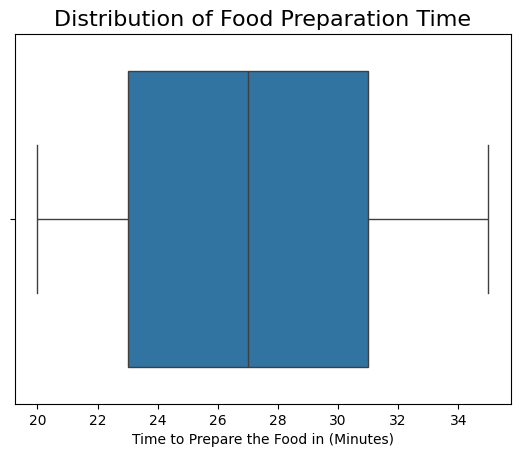

In [ ]:
# Distribution plot of Food Preparation time of the orders across the Food Hub platform
sns.boxplot(data=df,x='food_preparation_time')
plt.title('Distribution of Food Preparation Time',fontsize=16)
plt.xlabel('Time to Prepare the Food in (Minutes)')
plt.show()

**Observation**
* The median line sits exactly on the center of box at approximately 27 minutes. This means half of the order is prepared around 27 minutes and the other half takes longer.
* The whisker is between 20 mins and 35 mins which signifies the food is strictly under 20 mins and not more than 35 mins.
*  The median is centered and the whiskers are of equal length. Hence the plot is uniformly distributed. There is no outlier.
* There is no major delay in the food preparation time.


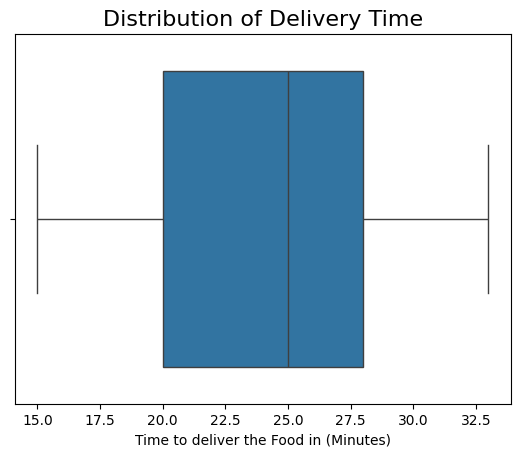

In [ ]:
# Distribution plot of Delivery time of the orders across the Food Hub platform
sns.boxplot(data=df,x='delivery_time')
plt.title('Distribution of Delivery Time',fontsize=16)
plt.xlabel('Time to deliver the Food in (Minutes)')
plt.show()

**Observation**
* The median line is around 25 mins. This means half of the order is delivered with 25 mins. Other half takes longer.
* Most of the delivery happens between 15 mins to 33 mins.
* The plot is slightly left skewed and most of the delivery is completed between 20 mins and 28 mins.
* There is no outlier which means the there was no extreme delay in delivery time


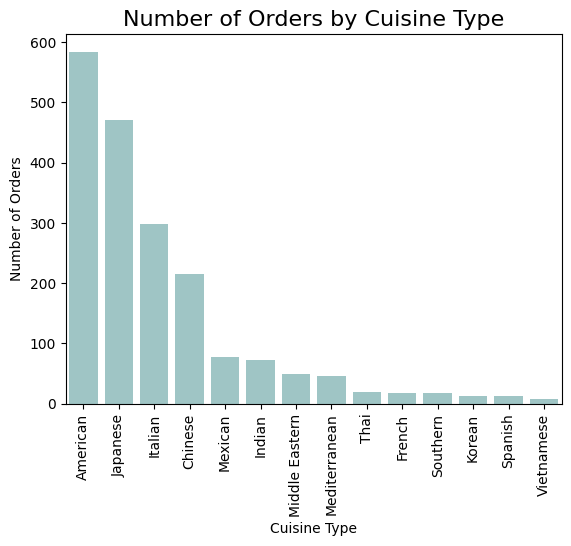

In [ ]:
# Most popular cuisine type based on number of orders received by the restaurant
order=df['cuisine_type'].value_counts().index
sns.countplot(data=df,x='cuisine_type',order=order,color='teal',alpha=0.4)
plt.xticks(rotation=90)
plt.title('Number of Orders by Cuisine Type',fontsize=16)
plt.xlabel('Cuisine Type')
plt.ylabel('Number of Orders')
plt.show()

**Observation**
* The most popular cuisine is American with approximate order of 580
* The second most popular cuisine is Japanese.
* The least favorite is Vietnamese




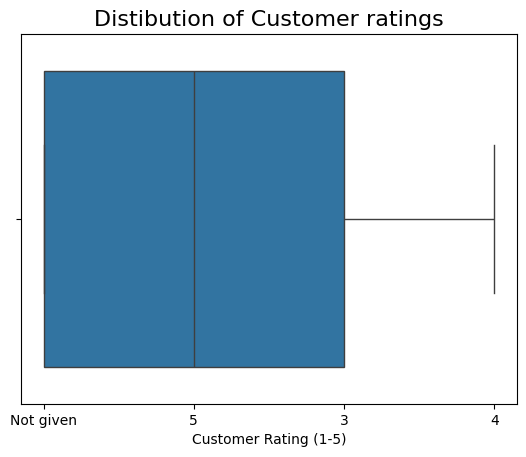

In [ ]:
#Distribution Plot of the customer ratings of the restaurant
sns.boxplot(data=df,x='rating')
plt.title('Distibution of Customer ratings',fontsize=16)
plt.xlabel('Customer Rating (1-5)')
plt.show()


**Observation**
* The Rating is a categorical discrete variable.
* The box is pushed toward the high end of the scale. representing the customers are highly satified.
* There is no rating below 2.

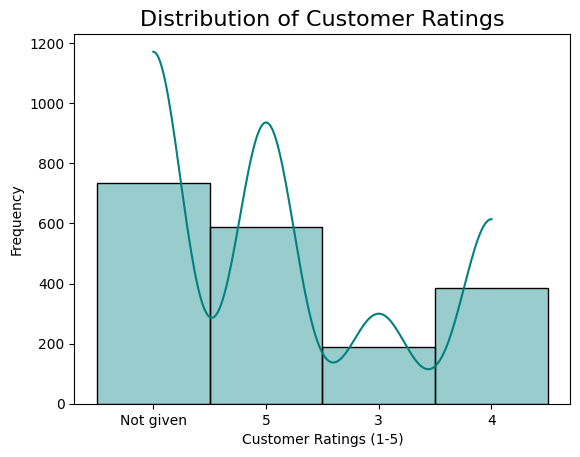

In [ ]:
# Distribution of customer rating of the restaurant
sns.histplot(data=df,x='rating',kde=True,color='Teal',alpha=0.4)
plt.title('Distribution of Customer Ratings',fontsize=16)
plt.xlabel('Customer Ratings (1-5)')
plt.ylabel('Frequency')
plt.show()

**Observation**
* The tall bar on 5 represents majority of the customers are highly satisfied with the Food Hub platform
* Around 40% of the customer has not given any ratings for the restaurant. This is a critical finding and significant portion of the order.
* The platform should create new strategies to convert the silent majority to provide feedbacks to improve the service to the restaurant.

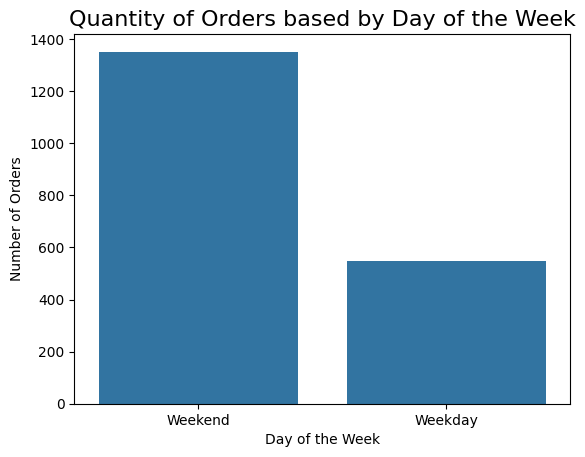

In [ ]:
#Number of orders served on weekdays and weekends
sns.countplot(data=df,x='day_of_the_week')
plt.title('Quantity of Orders based by Day of the Week',fontsize=16)
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.show()

**Observation**
* The number of orders served on a weekend is approximately 1350
* The number of orders served on a weekday is approximately 580.
* The restaurants serve more than half the weekday order during the weekend.
* The increase in food order during weekend could be because of other external factors.


### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
# Top 5 restuarants of the Food Hub Platform
print('The Top 5 restaurants in terms of the number of orders received:')
print(df.groupby('restaurant_name')['order_id'].count().nlargest());


The Top 5 restaurants in terms of the number of orders received:
restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: order_id, dtype: int64


#### Observations
* The most popular restaurant based on the number of order received is Shake Shack and it serves American cuisine.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Most popular cuisine during the weekend
print('The Most popular cuisine during the Weekend is ',df[df['day_of_the_week']=='Weekend']['cuisine_type'].value_counts().idxmax())


The Most popular cuisine during the Weekend is  American


#### Observations:
* The most popular cuisine during the weekends is American. There is no clear evidence why it is popular except Food Hub received most orders during weekends.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Write the code here
print('The percentage of orders that cost more than 20 dollars:')
percent=len(df[df['cost_of_the_order']>20])/len(df['order_id'])*100
print(percent)

The percentage of orders that cost more than 20 dollars:
29.24130663856691


#### Observations:
* Around 29% percentage of order cost was more than `20$`. This shows the spending behavior of the customers. There was not a lot of expensive orders.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Mean delivery time of the customer order by the restaurants

print('The mean order delivery time is:',df['delivery_time'].mean())

The mean order delivery time is: 24.161749209694417


#### Observations:
* The mean order delivery time is around 24 minutes. The median delivery time is 25 minutes. This means that some orders where delivered significantly faster to maintain the mean delivery time closer to median.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
#The top 3 customers who ordered most of the orders.
print('The top 3 customers are :')
print(df.groupby('customer_id').size().reset_index(name='order_count').sort_values(by='order_count',ascending=False).head(3))

The top 3 customers are :
     customer_id  order_count
116        52832           13
84         47440           10
333        83287            9


#### Observations:
* The top three customers are shown above. They have ordered 13,10,9 respectively. We don't know the duration of the data collection so can't decide the order number is healthy for the business.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


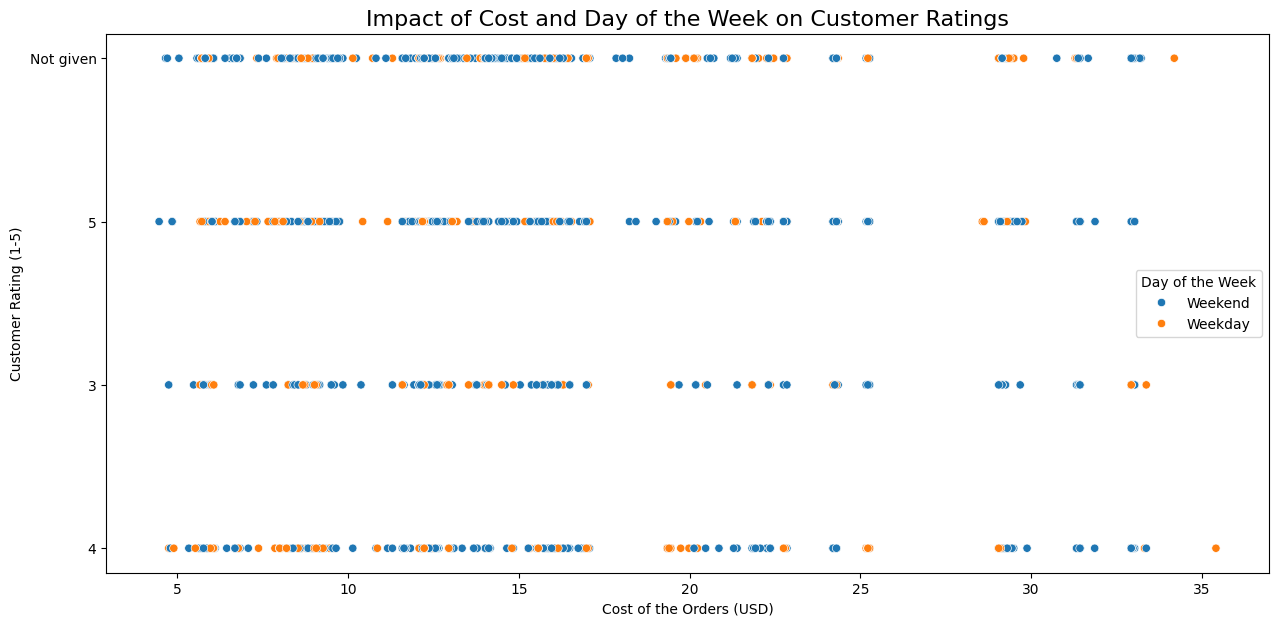

In [ ]:
# Bivariate analysis helps to explore the relations between numerical variables and between numerical & categorical variables
plt.figure(figsize=(15,7))
sns.scatterplot(data=df,x='cost_of_the_order',y='rating',hue='day_of_the_week')
plt.title('Impact of Cost and Day of the Week on Customer Ratings',fontsize=16)
plt.xlabel('Cost of the Orders (USD)')
plt.ylabel('Customer Rating (1-5)')
plt.legend(title='Day of the Week')
plt.show()

**Observation**


*   Low cost order is between `5$` - `10$`. The high cost order is between `25$` - `35$`.
*  The scatter plot shows that the cost of the order doesn't affect the rating from the customer.
* The plot shows the customers of Food Hub actively order food during weekend more than weekdays.The food  delivery is a leisure activity than a work habit.
* The 'Not Given' rating is so dense which means the customers are ordering food eventhough they have not given feedback. It signifies positive attitude towards Food Hub App.




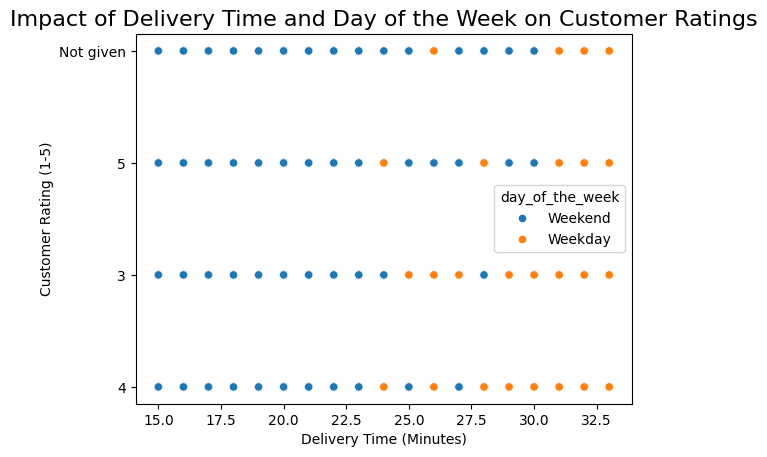

In [ ]:
# Customer Ratings based on delivery time and day of the week.
sns.scatterplot(data=df,x='delivery_time',y='rating',hue='day_of_the_week')
plt.title('Impact of Delivery Time and Day of the Week on Customer Ratings',fontsize=16)
plt.xlabel('Delivery Time (Minutes)')
plt.ylabel('Customer Rating (1-5)')
plt.show()


<Axes: xlabel='delivery_time', ylabel='rating'>

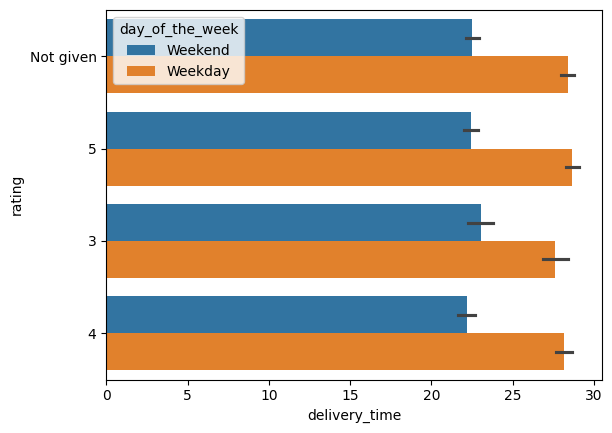

In [ ]:
sns.barplot(data=df,x='delivery_time',y='rating',hue='day_of_the_week')


####Observation
* The delivery time during weekend is between 15 mins and 24 mins. The delivery time during weekday is between 25 mins and 33 mins. Hence it is evident that the delivery time is faster during weekends.
* Eventhough there is clear difference in delivery speed, impact of rating is very low. This means the customers are happy as long as the delivery time is between 15 mins and 35 mins.
* The 'Not Given' rating follows the same pattern of the rated orders. Hence the customers who didn't rate the order is still happy but didnot give any feedback.


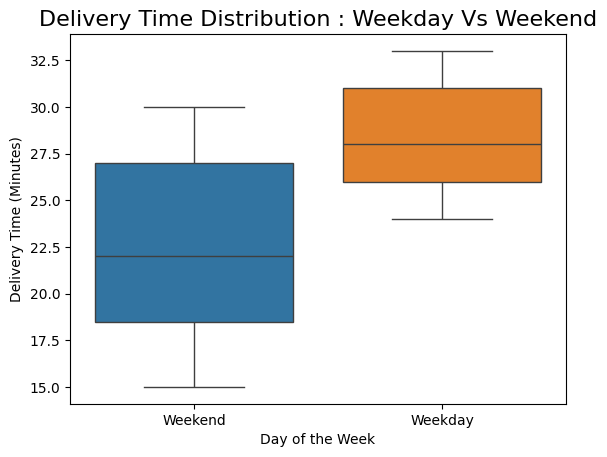

In [ ]:
# Delivery time distribution between Weekend and Weekday
sns.boxplot(data=df,x='day_of_the_week',y='delivery_time',hue='day_of_the_week')
plt.title('Delivery Time Distribution : Weekday Vs Weekend',fontsize=16)
plt.xlabel('Day of the Week')
plt.ylabel('Delivery Time (Minutes)')
plt.show()


####Observation
* The delivery time during the weekend is faster than the weekend.
* During the weekend, half of the orders are delivered around 22 mins and other half takes above 22 mins.
* During the weekdays, half of the orders are delivered around 28 mins and other half takes above 28 mins.
* The restaurant needs to investigate the reason for difference in delivery time during the weekdays

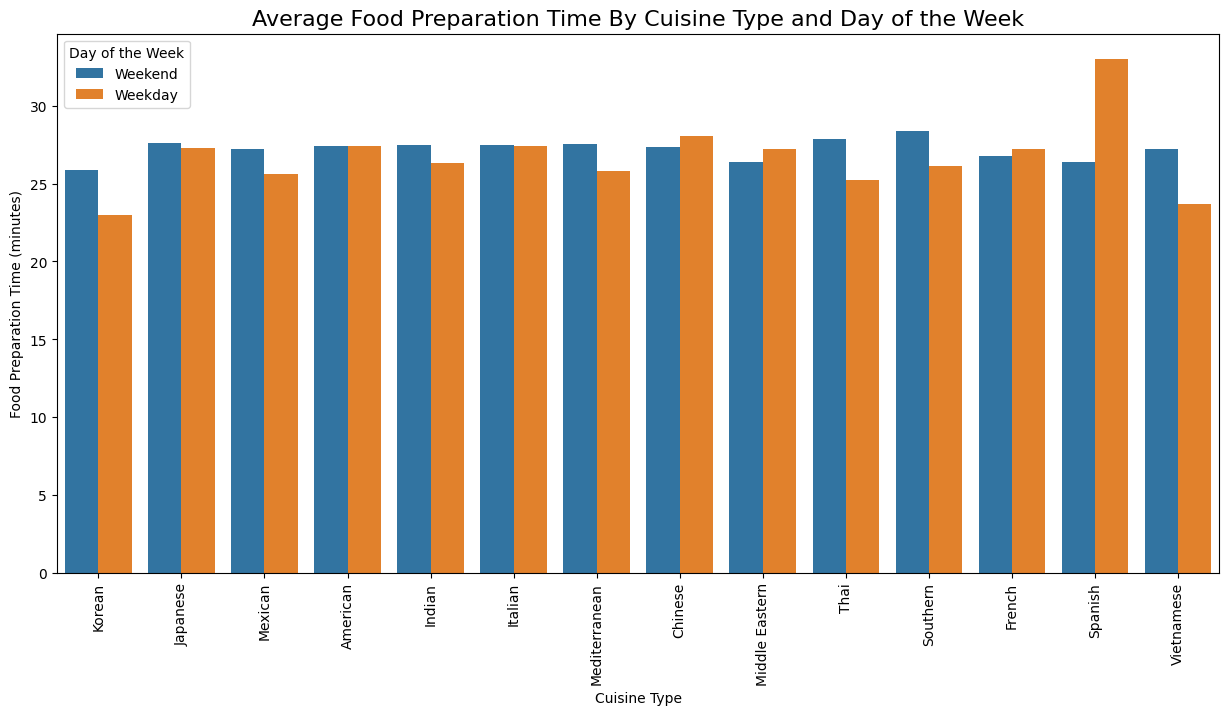

In [ ]:
# Impact of food preparation time based on the cuisine type
plt.figure(figsize=(15,7))
sns.barplot(data=df,x='cuisine_type',y='food_preparation_time',hue='day_of_the_week',errorbar=None)
plt.title('Average Food Preparation Time By Cuisine Type and Day of the Week',fontsize=16)
plt.xlabel('Cuisine Type')
plt.ylabel('Food Preparation Time (minutes)')

plt.xticks(rotation=90)
plt.legend(title='Day of the Week')
plt.show()



####Observation
* The most striking feature of the chart is the bars are mostly on the same level. This means the kitchens of all cuisine has highly standardized kitchen workflows to support food preparation
* Spanish cuisine alone more than 30 mins to prepare the food during weekdays. Weekends preparation time is faster.
* The American and Italian kitchens are able to prepare the food around the same time irrespective of the day of the week.
* The Korean, Vietnamese, Thai and Southern food is prepared takes longer during weekends than on weekdays.
* The Chinese, Middle Eastern and French foods takes slightly longer to prepare during the weekdays than weekends. The bar chart shows slightly significant difference and hence can be ignored.

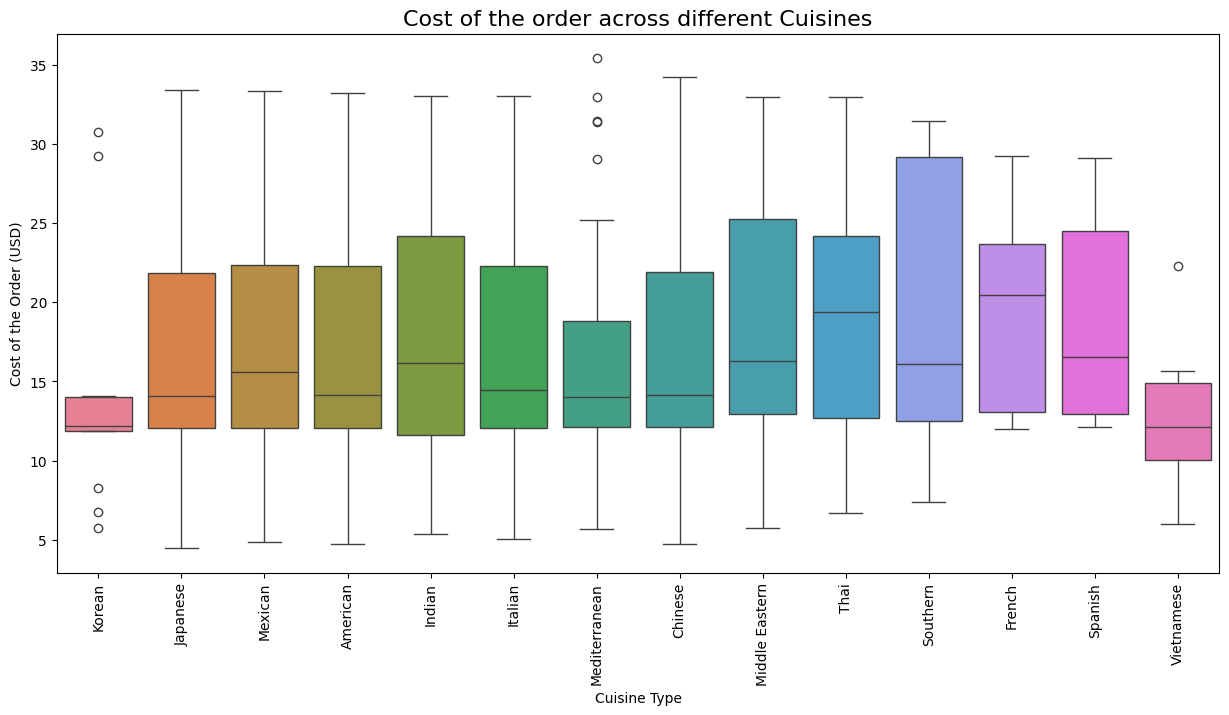

In [ ]:
# The Difference in cost of the orders based on the different cuisines
plt.figure(figsize=(15,7))
sns.boxplot(data=df,x='cuisine_type',y='cost_of_the_order',hue='cuisine_type')
plt.xticks(rotation=90)
plt.title('Cost of the order across different Cuisines',fontsize=16)
plt.xlabel('Cuisine Type')
plt.ylabel('Cost of the Order (USD)')

plt.xticks(rotation=90)
plt.show()

####Observation
* The Korean and Vietnamese cuisines are budget friendly options in the platform. The interesting fact about Korean cuisine is there are some outliers on the bottom which means some customers have placed some extremely cheap orders.
* The American, Italian, Indian and Japanese shows similiar pattern. Their median is around `$14` - `$16`. These are popular cuisines and the customers have specific budget in their mind when ordering
* The Korean and Vietnamese cuisines has short boxes which means they have a standardized pricing across the menu.
* The Southern, Middle East, Spanish and Thai have tall boxes. It means the cost of the order depends on what you order
* The Mediterrean cuisine some outlier on the top which means there are specific orders which are large.
* The French and Thai median is `$20` which corresponds to premium cuisine in the dataset.

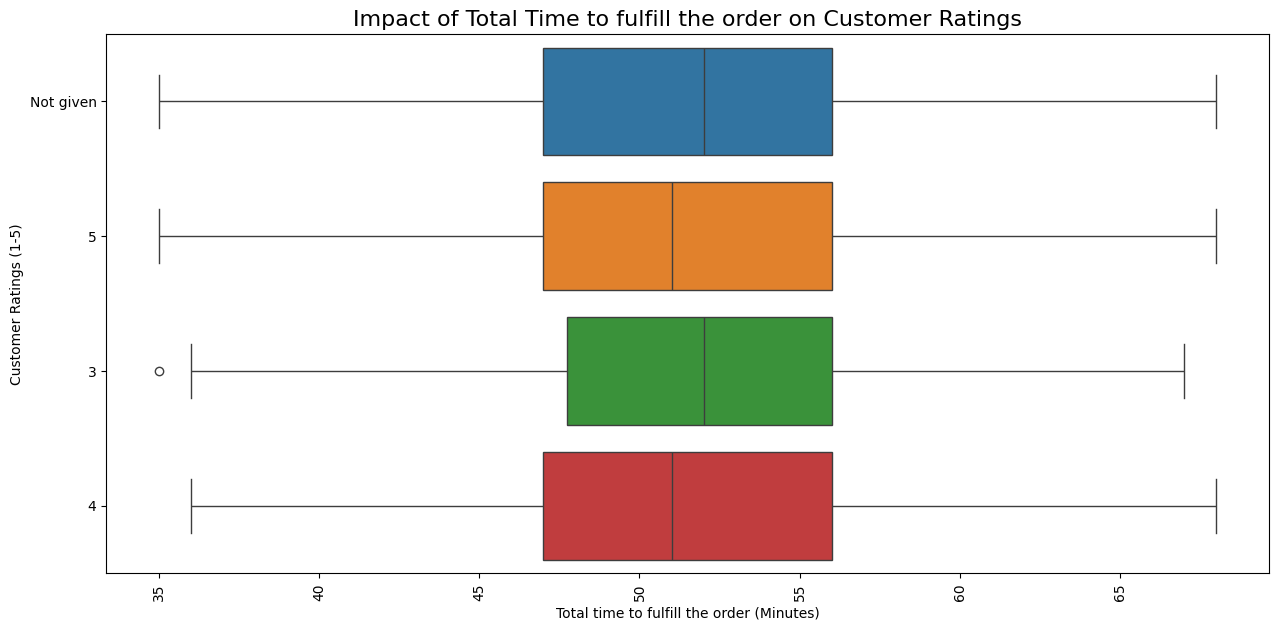

In [ ]:

plt.figure(figsize=(15,7))
df['total_time']=df['food_preparation_time']+df['delivery_time']
sns.boxplot(data=df,x='total_time',y='rating',hue='rating')
plt.xticks(rotation=90)
plt.title('Impact of Total Time to fulfill the order on Customer Ratings',fontsize=16)
plt.xlabel('Total time to fulfill the order (Minutes)')
plt.ylabel('Customer Ratings (1-5)')

plt.xticks(rotation=90)
plt.show()

#### Observation
* Most significant finding is that the time to fulfill the order doesn't impact the ratings of the customer.
* The median of the total time to fulfill the order for all the ratings is around 52 mins - 53 mins. This shows the most of the customers gets their order delivered within an hour from ordering.
* The total delivery time for all the ratings including 'Not given' falls between 47 mins - 56 mins. The business is consistent in delivering the major orders to their customers.
* The outlier in the rating 3 suggest that the business was able to deliver the food in 35 mins. Even though the food was delivered faster, the rating was low. It is evident there other factors that affects the rating of the customer.

In [ ]:
# Correlation Matrix of the numerical variables
corr=df[['cost_of_the_order','food_preparation_time','delivery_time']].corr()
print(corr)


                       cost_of_the_order  food_preparation_time  delivery_time
cost_of_the_order               1.000000               0.041527      -0.029949
food_preparation_time           0.041527               1.000000       0.011094
delivery_time                  -0.029949               0.011094       1.000000


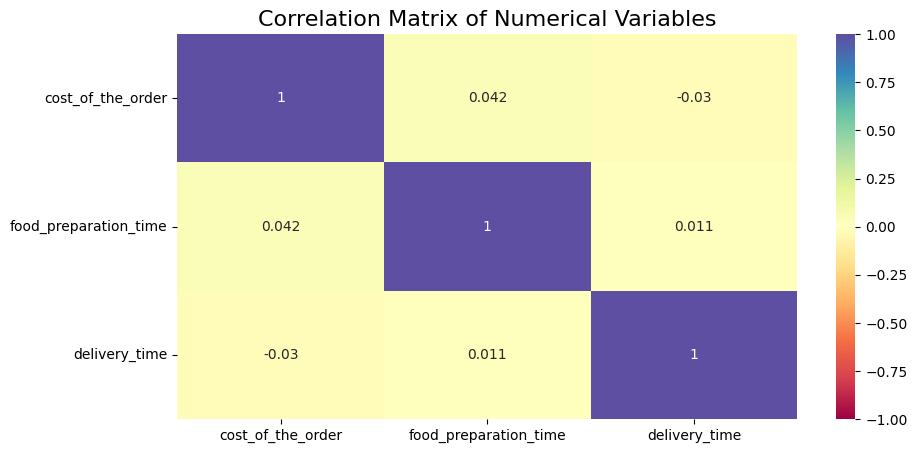

In [ ]:
# Correlation Matrix of the numerical variables
plt.figure(figsize=(10,5))
sns.heatmap(corr,annot=True,cmap='Spectral',vmin=-1,vmax=1)
plt.title('Correlation Matrix of Numerical Variables',fontsize=16)
plt.show()

####Observation
* The correlation between the order cost and the preparation time is 0.042. This is a weak positive coorelation. It shows that order cost doesn't impact the preparation time.
* The correlation between preparation time and delivery time is 0.011. It is so small. This shows the delivery time and preparation time are two different independent stage in the platform.
* The coorelation between the order cost and delivery time is -0.03. It is evident that the cost of the order doesn't impact the delivery time

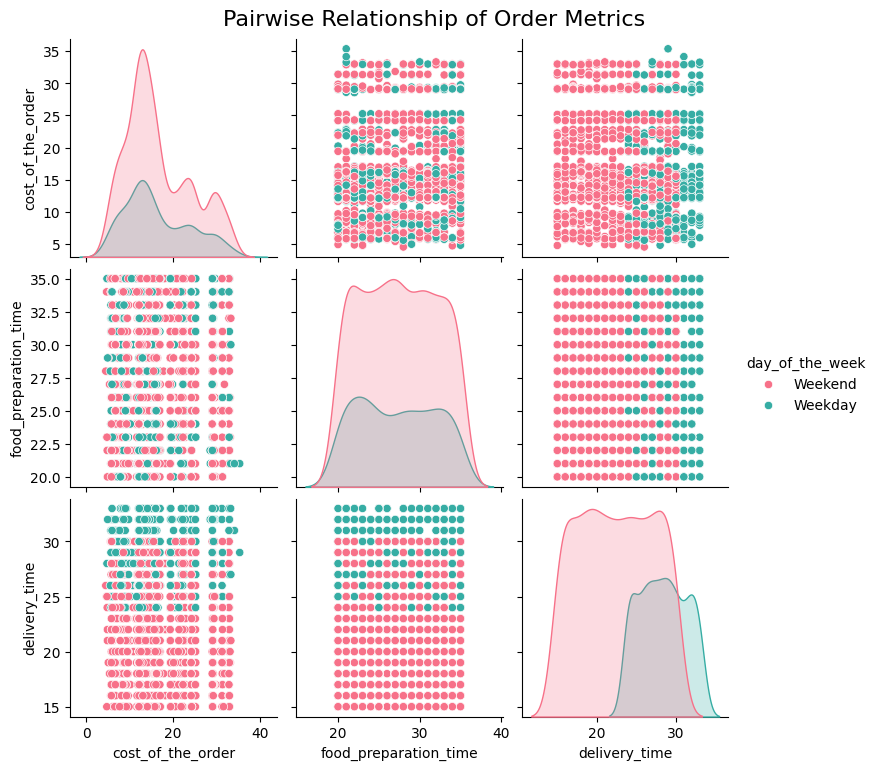

In [ ]:
# The pairwise Relationship of the Order Metrics

sns.pairplot(df,vars=['cost_of_the_order','food_preparation_time','delivery_time'],hue='day_of_the_week',palette='husl')
plt.suptitle('Pairwise Relationship of Order Metrics',y=1.02,fontsize=16)
plt.show()

####Observation
* There is no clear correlation ship between cost order and delivery time or preparation time.
* The order cost has peaks at `$12,$25,$30`. Hence the customers tend to cluster around this specific price point.
* The platform gets high orders during weekend and they efficiently handle the delivery during the weekend.
* The preparation time is uniform during the weekend and weekday. This represents kitchen is well equipped handle all volumes of order.
* There is clear distinction between delivery time during weekend and weekday. Weekend delivery are faster than weekday delivery time.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# List of restaurant that has average rating more than 4 and are rated by more than 50.
df['rating_numeric']=pd.to_numeric(df['rating'],errors='coerce')
top_restaurant=df.groupby('restaurant_name').filter(lambda x:x['rating'].count()>50 and x['rating_numeric'].mean()>4).sort_values(by='rating_numeric',ascending=False)
print('The restaurant that have a rating count of more than 50 and the average rating greater than 4 are :')
for name in top_restaurant['restaurant_name'].unique():
  print(name)

The restaurant that have a rating count of more than 50 and the average rating greater than 4 are :
The Meatball Shop
Shake Shack
Blue Ribbon Sushi
RedFarm Broadway
Blue Ribbon Fried Chicken
Parm
RedFarm Hudson


#### Observations:
* There are only 7 restaurants that has an average rating more than 4 and are rated by 50 more customers. They represents the operational excellence.  
* These 7 restaurants represents the current powerhouse of Food Hub platform in terms of revenue generation.
* The top rated cuisines are Italian, American, Chinese and Japanese are customer favorites.
* There is a group of customers who have not rated when encouraged to rate can change the top list.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# The net revenue of the Food Hub based on sales commission
revenue=np.where(df['cost_of_the_order']>20,df['cost_of_the_order']*0.25,np.where(df['cost_of_the_order']>5*0.15,df['cost_of_the_order']*0.15,0))
print('The net revenue generated by the company accross the orders is : $',revenue.sum())

The net revenue generated by the company accross the orders is : $ 6172.714


#### Observations:
* The net revenue generated by Food Hub is `$6173`. There is no clear mention duration of the data representation.
* Since all the order cost falls above `$5`, the company will have a steady income as most of the order will fall in the 15% bracket. The expensive orders will give more space for the growth.


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# The percentage of order that took more than 60 minutes to fullfil the order
print('The percentage of orders that take more than 60 minutes is :',round((df['total_time']>60).mean()*100,2))

The percentage of orders that take more than 60 minutes is : 10.54


#### Observations:
* Only 10.5% of order took more than an hour to deliver the order.
* This is one of the factor the company should focus to improve their revenue. Improving the delivery by few minutes can drop the percentage signficantly.
* Improving the Weekday delivery time is something Food Hub platform should look into.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# Difference in the delivery time between weekend and weeekday
df.groupby('day_of_the_week').delivery_time.mean()

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations:
* There is huge difference of 6 minutes of average delivery time between weekend and weekday. Usually it is expected that the weekend orders are delivered but it is the other way round.
* The platform should recommend the restaurants to improve the weekday delivery time.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  Even though there is no statistical correlation between order cost or delivery time and customer rating. But 40% of customer has not rated which creates a massive gap.
* The restaurants have a stable food preparation time and delivery time which is a major assest for the customer trust building.
* The restaurants works faster on the weekends than weekdays based on the delivery time. This could be because of they have more drivers to deliver the food.
* Revenue currently concentrated on the standard cuisine like American, Italian and Japanese. But the average order cost is around `$12` - `$15`. They fall under the 15% bracket.



### Recommendations:

*  The French, Italian and Thai have higher median and high satisfaction rate. Thus the platform should encourage weekend targeted promotions for high orders of premium categories. This will generate more revenue for the platform
* The Spanish cuisine has slow order fullfilment during weekends. More investigation to rectify the problem will increase the order and thus more revenue.
* The 'Not Given' rating is around 40% and it is large gap. Hence some incentive or loyalty program to encourage the customers to give feedback should be implemented
* Weekday delivery time is always slower than weekend delivery. The investigation to identify the delay is because of traffic or less available drivers and fixing it will speed up the weekday delivery time. Maintaining the delivery time consistently below 60 minutes will build the customer trust based on the weekend data
* The business can use a better commission tier. Major order cost is between `$12` - `$15`. Adding another commission tier for range will increase the net revenue.

---